In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = Path(r"C:\Users\orxan\OneDrive\Masaüstü\prediction_hub\PredictBack\predicthub_backend\ml\data\synthetic")

df = pd.read_csv(path / "trades.csv")

df.head()

,id,user_id,market_id,outcome_type,trade_type,amount_staked,tokens_amount,price_at_execution,onchain_trade_id,onchain_tx_hash,created_at
0,9518,343,43,YES,buy,5.69,9.22,0.617188,704744,0x08a6ee02814c,2025-12-01T00:44:53.699582+00:00
1,9517,343,24,NO,buy,27.48,72.52,0.378937,682598,0x0bbbaa05fa91,2025-12-01T00:14:51.699582+00:00
2,9516,343,21,NO,buy,19.25,35.01,0.549838,884372,0x02b7d408b64c,2025-11-30T23:37:36.699582+00:00
3,11367,443,41,YES,buy,18.41,33.20,0.554495,609407,0x0d269f02c62a,2025-11-30T23:35:45.772966+00:00
4,11366,443,18,NO,buy,13.51,44.56,0.303211,861836,0x03063a0d26f2,2025-11-30T23:18:43.772966+00:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9572 entries, 0 to 9571
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  9572 non-null   int64  
 1   user_id             9572 non-null   int64  
 2   market_id           9572 non-null   int64  
 3   outcome_type        9572 non-null   object 
 4   trade_type          9572 non-null   object 
 5   amount_staked       9572 non-null   float64
 6   tokens_amount       9572 non-null   float64
 7   price_at_execution  9572 non-null   float64
 8   onchain_trade_id    9572 non-null   int64  
 9   onchain_tx_hash     9572 non-null   object 
 10  created_at          9572 non-null   object 
dtypes: float64(3), int64(4), object(4)
memory usage: 822.7+ KB


In [6]:
df.describe()

,id,user_id,market_id,amount_staked,tokens_amount,price_at_execution,onchain_trade_id
count,9572.000000,9572.000000,9572.000000,9572.000000,9572.000000,9572.000000,9572.000000
mean,8790.500000,308.501567,29.433243,72.417925,153.405080,0.500590,505414.335562
std,2763.342722,144.000026,8.623605,113.923291,251.919615,0.116451,290465.760630
min,4005.000000,57.000000,15.000000,1.000000,1.530000,0.300035,1271.000000
25%,6397.750000,186.000000,22.000000,16.030000,32.175000,0.398251,255357.000000
50%,8790.500000,306.000000,29.000000,30.795000,61.080000,0.500001,505504.000000
75%,11183.250000,433.000000,37.000000,45.352500,103.355000,0.601226,760024.500000
max,13576.000000,556.000000,44.000000,499.840000,1661.650000,0.699996,999763.000000


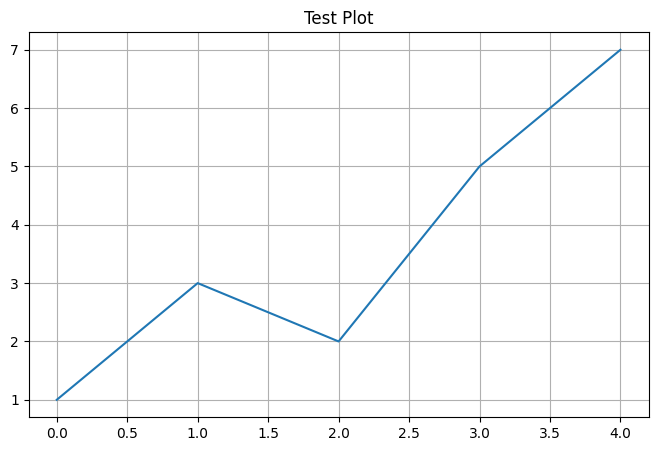

In [8]:
# Make plots look a bit nicer
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

plt.plot([1, 3, 2, 5, 7])
plt.title("Test Plot")
plt.show()

In [10]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths (adjust if needed)

# Set project root manually relative to notebook
PROJECT_ROOT = Path("..").resolve().parent   


DATA_DIR = PROJECT_ROOT / "ml" / "data" / "synthetic"
TRADES_CSV = DATA_DIR / "trades.csv"

print("Project root:", PROJECT_ROOT)
print("Trades CSV exists:", TRADES_CSV.exists())


Project root: C:\Users\orxan\OneDrive\Masaüstü\prediction_hub\PredictBack\predicthub_backend
Trades CSV exists: True


In [13]:
# In[4]: Parse dates and sort

if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"])
else:
    raise ValueError("created_at column is required for time-based features")

# Ensure consistent ordering for time-based features
df = df.sort_values(["user_id", "created_at"]).reset_index(drop=True)
df.head()

,id,user_id,market_id,outcome_type,trade_type,amount_staked,tokens_amount,price_at_execution,onchain_trade_id,onchain_tx_hash,created_at
0,4005,57,26,NO,buy,11.92,21.13,0.564013,293136,0x07e6bd06c72f,2025-11-23 09:03:51.031124+00:00
1,4006,57,17,NO,sell,32.43,70.52,0.459871,348235,0x0f06420a1af6,2025-11-23 10:03:01.031124+00:00
2,4007,57,18,NO,buy,29.45,42.47,0.693420,626550,0x0223530342a4,2025-11-23 10:05:04.031124+00:00
3,4008,57,26,NO,sell,30.70,60.84,0.504569,200312,0x07b0620ac054,2025-11-23 10:34:53.031124+00:00
4,4009,57,16,NO,buy,26.48,42.53,0.622604,986937,0x0c83fd0d0969,2025-11-23 10:52:26.031124+00:00


In [14]:
# Time since last trade per user (seconds)
df["time_since_last_trade"] = (
    df.groupby("user_id")["created_at"]
             .diff()
             .dt.total_seconds()
)

In [ ]:
df['time_since_last_trade'] #first trades are 0

0          NaN
1       3550.0
2        123.0
3       1789.0
4       1053.0
         ...  
9567    2079.0
9568    3588.0
9569     288.0
9570     122.0
9571    1943.0
Name: time_since_last_trade, Length: 9572, dtype: float64

In [16]:
# First trade for each user will have NaN -> fill with 0
df["time_since_last_trade"] = df["time_since_last_trade"].fillna(0.0)

# Hour of day (0–23)
df["hour_of_day"] = df["created_at"].dt.hour

df[[
    "id", "user_id", "created_at",
    "amount_staked", "time_since_last_trade", "hour_of_day"
]].head(10)

,id,user_id,created_at,amount_staked,time_since_last_trade,hour_of_day
0,4005,57,2025-11-23 09:03:51.031124+00:00,11.92,0.0,9
1,4006,57,2025-11-23 10:03:01.031124+00:00,32.43,3550.0,10
2,4007,57,2025-11-23 10:05:04.031124+00:00,29.45,123.0,10
3,4008,57,2025-11-23 10:34:53.031124+00:00,30.70,1789.0,10
4,4009,57,2025-11-23 10:52:26.031124+00:00,26.48,1053.0,10
5,4010,57,2025-11-23 11:43:15.031124+00:00,22.13,3049.0,11
6,4011,57,2025-11-23 12:28:42.031124+00:00,25.85,2727.0,12
7,4012,57,2025-11-23 12:49:03.031124+00:00,21.60,1221.0,12
8,4013,57,2025-11-23 13:01:05.031124+00:00,27.85,722.0,13
9,4014,57,2025-11-23 13:54:53.031124+00:00,22.65,3228.0,13


In [18]:
user_trade_count = (
    df.groupby("user_id")["id"]
             .count()
             .rename("user_total_trades")
) #total trades per user


In [20]:
# Average stake per user
user_avg_stake = (
    df.groupby("user_id")["amount_staked"]
             .mean()
             .rename("user_avg_stake")
)

In [21]:
# Join back to trades

df = df.merge(
    user_trade_count, on="user_id", how="left"
).merge(
    user_avg_stake, on="user_id", how="left"
)

In [23]:
df[[
    "user_id", "amount_staked", "user_total_trades", "user_avg_stake"
]].head()

,user_id,amount_staked,user_total_trades,user_avg_stake
0,57,11.92,21,21.286667
1,57,32.43,21,21.286667
2,57,29.45,21,21.286667
3,57,30.70,21,21.286667
4,57,26.48,21,21.286667


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9572 entries, 0 to 9571
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     9572 non-null   int64              
 1   user_id                9572 non-null   int64              
 2   market_id              9572 non-null   int64              
 3   outcome_type           9572 non-null   object             
 4   trade_type             9572 non-null   object             
 5   amount_staked          9572 non-null   float64            
 6   tokens_amount          9572 non-null   float64            
 7   price_at_execution     9572 non-null   float64            
 8   onchain_trade_id       9572 non-null   int64              
 9   onchain_tx_hash        9572 non-null   object             
 10  created_at             9572 non-null   datetime64[ns, UTC]
 11  time_since_last_trade  9572 non-null   float64          

In [26]:
# In[7]: Select features for anomaly detection

feature_cols = [
    "amount_staked",
    "time_since_last_trade",
    "hour_of_day",
    "user_total_trades",
    "user_avg_stake",
]

missing_cols = [c for c in feature_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected feature columns: {missing_cols}")

X = df[feature_cols].astype(float).values
print("Feature matrix shape:", X.shape)


Feature matrix shape: (9572, 5)


In [29]:
# In[8]: Scale features indisipensible in DS for model training

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature mean (approx):", X_scaled.mean(axis=0))
print("Scaled feature std (approx):", X_scaled.std(axis=0))


Scaled feature mean (approx): [ 4.15695708e-17  5.34465911e-17  1.39554988e-16  2.73171465e-16
 -1.18770202e-16]
Scaled feature std (approx): [1. 1. 1. 1. 1.]


In [31]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(
    eps=0.8,        # yaxınlıq radiusu (scaled space-də)
    min_samples=10  # bir klaster üçün minimum nümunə sayı
)

db_labels = dbscan.fit_predict(X_scaled)

# Nəticələri dataframe-ə əlavə edirik
df["dbscan_cluster"] = db_labels

unique_clusters, counts = np.unique(db_labels, return_counts=True)
print("Clusters and counts:")
for c, cnt in zip(unique_clusters, counts):
    if c == -1:
        print(f"  Cluster -1 (noise/outliers): {cnt} trades")
    else:
        print(f"  Cluster {c}: {cnt} trades")

Clusters and counts:
  Cluster -1 (noise/outliers): 5 trades
  Cluster 0: 7866 trades
  Cluster 1: 1701 trades


In [32]:
# Yalnız noise (outlier) olan tradelər
df_db_outliers = df[df["dbscan_cluster"] == -1]

print("Total DBSCAN outliers:", len(df_db_outliers))
df_db_outliers[[
    "id", "user_id", "market_id",
    "amount_staked", "time_since_last_trade",
    "dbscan_cluster"
]].head(10)


Total DBSCAN outliers: 5


,id,user_id,market_id,amount_staked,time_since_last_trade,dbscan_cluster
725,4730,94,35,31.04,1945.0,-1
3367,7372,236,25,14.45,3424.0,-1
5512,9517,343,24,27.48,2235.0,-1
5513,9518,343,43,5.69,1802.0,-1
7875,11880,468,32,45.91,2901.0,-1


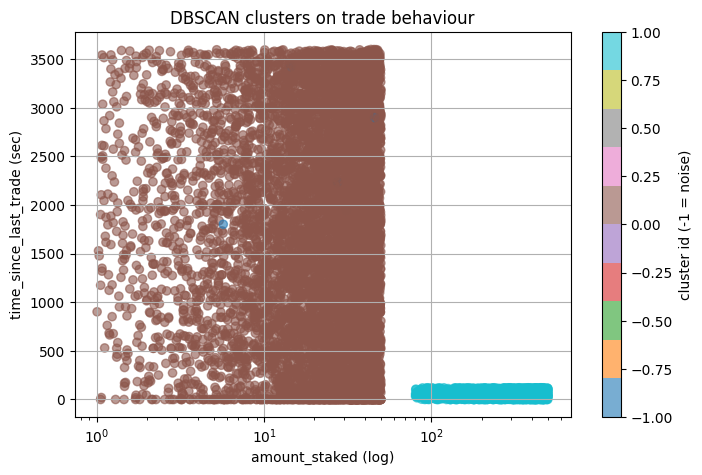

In [33]:
import matplotlib.pyplot as plt

# Sadəcə 2 feature seçək plot üçün
x = df["amount_staked"]
y = df["time_since_last_trade"]
clusters = df["dbscan_cluster"]

plt.figure(figsize=(8, 5))
scatter = plt.scatter(x, y, c=clusters, cmap="tab10", alpha=0.6)
plt.xscale("log")
plt.xlabel("amount_staked (log)")
plt.ylabel("time_since_last_trade (sec)")
plt.title("DBSCAN clusters on trade behaviour")
plt.colorbar(scatter, label="cluster id (-1 = noise)")
plt.show()


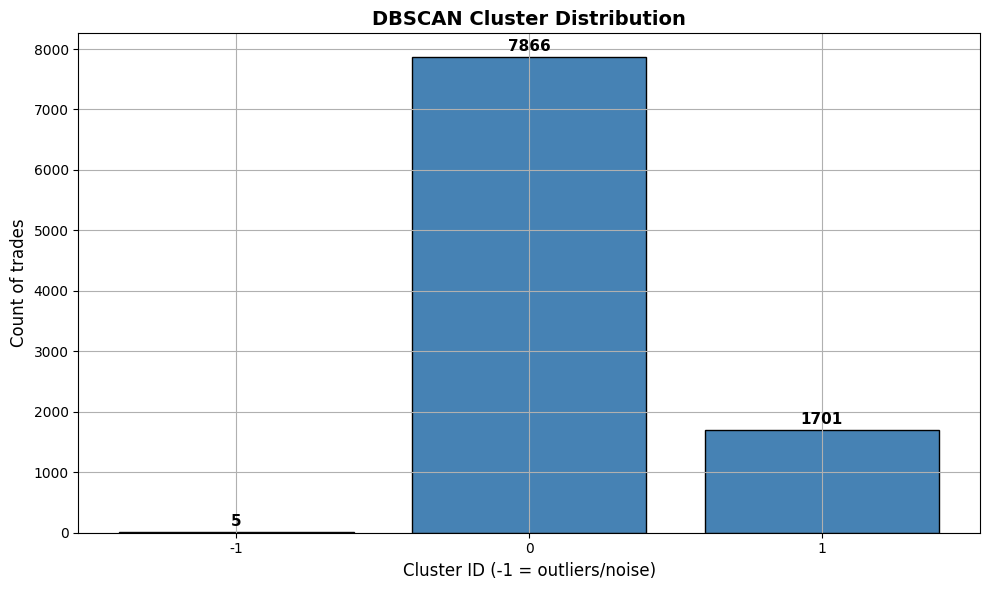

In [49]:
# In[XX]: DBSCAN cluster distribution

plt.figure(figsize=(10, 6))

cluster_counts = df["dbscan_cluster"].value_counts().sort_index()

colors = ['red' if idx == -1 else 'steelblue' for idx in cluster_counts.index]

bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, 
               edgecolor='black', color=colors)

# Add count labels on top of each bar
for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("DBSCAN Cluster Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Cluster ID (-1 = outliers/noise)", fontsize=12)
plt.ylabel("Count of trades", fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
#  Train Isolation Forest model

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,      # assume ~15% of trades are anomalous
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

iso_model.fit(X_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [ ]:
# decision_function: higher = more normal, lower = more anomalous
decision_scores = iso_model.decision_function(X_scaled)  # shape (n_samples,)
pred_labels = iso_model.predict(X_scaled)  # 1 = normal, -1 = anomaly

df["iforest_raw_score"] = decision_scores
df["iforest_label"] = pred_labels
#trade_1	0.25 → normal
#trade_2	-0.02 → yüngül anomaliya
#trade_3	-0.45 → çox riskli

In [36]:
# In[10]: Convert raw scores to 0–1 risk_score (higher = more risky)

# We invert sign because decision_function: low = anomalous
s = -df["iforest_raw_score"].values
s_min, s_max = s.min(), s.max()
df["risk_score"] = (s - s_min) / (s_max - s_min + 1e-9)

# Choose threshold, e.g. top 20% most risky trades
threshold = df["risk_score"].quantile(0.80)
df["is_suspicious"] = df["risk_score"] >= threshold

df[[
    "id", "user_id", "amount_staked", "time_since_last_trade",
    "risk_score", "is_suspicious"
]].head(15)


,id,user_id,amount_staked,time_since_last_trade,risk_score,is_suspicious
0,4005,57,11.92,0.0,0.308908,False
1,4006,57,32.43,3550.0,0.505572,True
2,4007,57,29.45,123.0,0.243155,False
3,4008,57,30.70,1789.0,0.233310,False
4,4009,57,26.48,1053.0,0.224804,False
5,4010,57,22.13,3049.0,0.270324,False
6,4011,57,25.85,2727.0,0.249319,False
7,4012,57,21.60,1221.0,0.156869,False
8,4013,57,27.85,722.0,0.170586,False
9,4014,57,22.65,3228.0,0.295540,False


In [37]:
# : Global suspicious rate

suspicious_rate = df["is_suspicious"].mean()
print(f"Suspicious trade rate: {suspicious_rate * 100:.2f}%")


Suspicious trade rate: 20.01%


In [43]:
# In[12]: Suspicious trades by user

user_suspicious_stats = (
    df.groupby("user_id")["is_suspicious"]
             .mean()
             .rename("user_suspicious_rate")
             .to_frame()
    .join(
        df.groupby("user_id")["id"].count()
                 .rename("user_trade_count")
    )
    .sort_values("user_suspicious_rate", ascending=False)
)

user_suspicious_stats.head(15)


,user_suspicious_rate,user_trade_count
user_id,,
551,1.0,21
512,1.0,20
119,1.0,20
418,1.0,21
164,1.0,24
175,1.0,20
411,1.0,25
454,1.0,20
453,1.0,21


In [44]:
# In[13]: Top suspicious trades (for inspection / debugging)

top_suspicious_trades = (
    df.sort_values("risk_score", ascending=False)
             .head(20)
[[
    "id", "user_id", "market_id",
    "amount_staked", "time_since_last_trade",
    "risk_score", "is_suspicious", "created_at"
]]
)

top_suspicious_trades


,id,user_id,market_id,amount_staked,time_since_last_trade,risk_score,is_suspicious,created_at
6294,10299,387,38,497.46,107.0,1.000000,True,2025-11-25 09:10:50.828629+00:00
5425,9430,340,29,493.97,6.0,0.979180,True,2025-11-27 09:04:17.451566+00:00
6299,10304,387,16,479.92,11.0,0.974733,True,2025-11-25 09:15:51.828629+00:00
5460,9465,341,44,450.83,12.0,0.953509,True,2025-11-30 09:18:36.527392+00:00
7547,11552,454,20,451.01,120.0,0.943210,True,2025-11-26 09:11:58.501047+00:00
5751,9756,356,42,474.80,0.0,0.925332,True,2025-11-24 09:04:12.756770+00:00
2992,6997,217,33,481.87,3.0,0.922660,True,2025-11-30 09:10:23.269277+00:00
5454,9459,341,31,422.58,117.0,0.921147,True,2025-11-30 09:14:12.527392+00:00
5456,9461,341,37,452.47,38.0,0.919828,True,2025-11-30 09:15:04.527392+00:00
7297,11302,441,17,480.11,113.0,0.918774,True,2025-11-27 09:09:17.599998+00:00


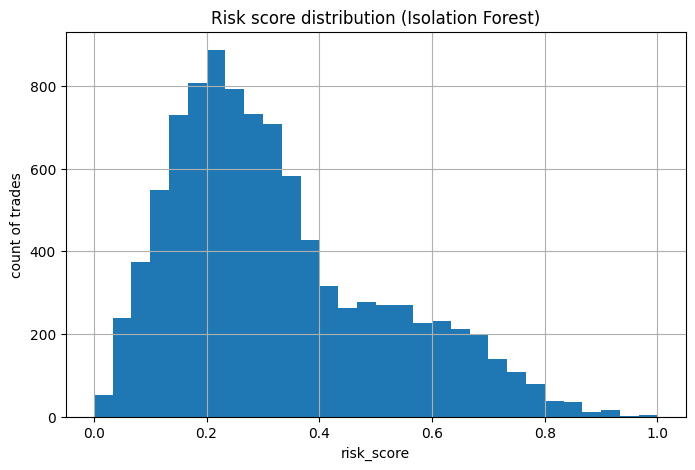

In [45]:
# In[14]: Risk score distribution

plt.hist(df["risk_score"], bins=30)
plt.title("Risk score distribution (Isolation Forest)")
plt.xlabel("risk_score")
plt.ylabel("count of trades")
plt.show()


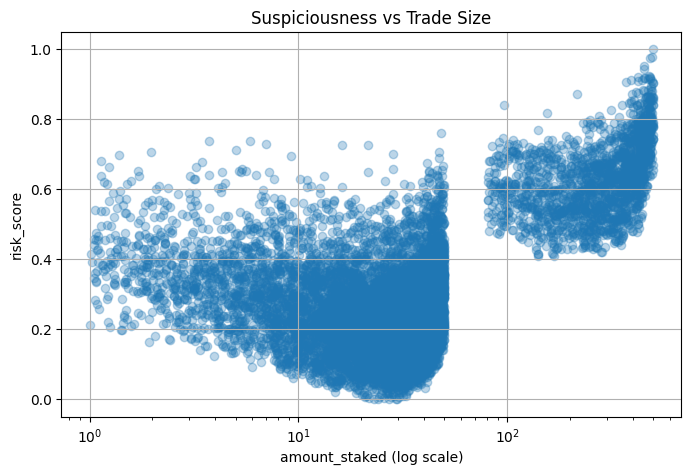

In [50]:
# In[15]: Amount vs Risk scatter (log scale for amount)

plt.scatter(
    df["amount_staked"],
    df["risk_score"],
    alpha=0.3,
)
plt.xscale("log")
plt.xlabel("amount_staked (log scale)")
plt.ylabel("risk_score")
plt.title("Suspiciousness vs Trade Size")
plt.show()


In [51]:
import numpy as np

# How many trades?
n_trades = len(df)
# How many marked as anomaly? (-1 = anomaly)
n_anomalies = (df["iforest_label"] == -1).sum()
anomaly_ratio = n_anomalies / n_trades

print(f"Total trades: {n_trades}")
print(f"Anomalies detected: {n_anomalies}")
print(f"Anomaly ratio: {anomaly_ratio * 100:.2f}%")

# Score statistics
scores = df["iforest_raw_score"].values

print("\nScore statistics:")
print(f"  Mean score: {np.mean(scores):.4f}")
print(f"  Std score:  {np.std(scores):.4f}")
print(f"  5% quantile:  {np.quantile(scores, 0.05):.4f}")
print(f"  50% quantile (median): {np.quantile(scores, 0.50):.4f}")
print(f"  95% quantile: {np.quantile(scores, 0.95):.4f}")

Total trades: 9572
Anomalies detected: 479
Anomaly ratio: 5.00%

Score statistics:
  Mean score: 0.0854
  Std score:  0.0433
  5% quantile:  -0.0000
  50% quantile (median): 0.0951
  95% quantile: 0.1410


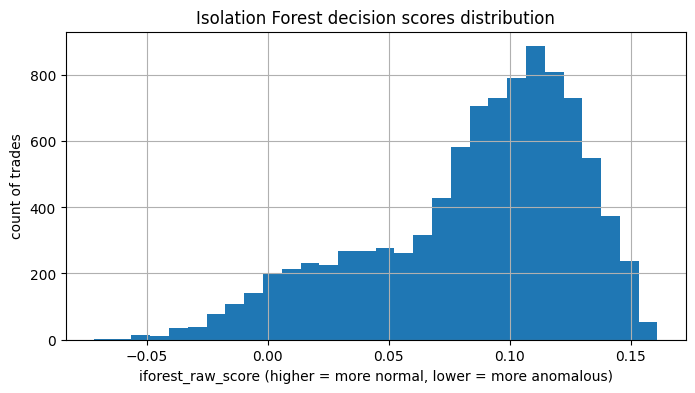

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df["iforest_raw_score"], bins=30)
plt.title("Isolation Forest decision scores distribution")
plt.xlabel("iforest_raw_score (higher = more normal, lower = more anomalous)")
plt.ylabel("count of trades")
plt.show()


In [53]:
from sklearn.ensemble import IsolationForest

n_bootstrap = 10        # Train model 10 times
all_scores = []

for seed in range(n_bootstrap):
    model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        max_samples="auto",
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(X_scaled)
    s = model.decision_function(X_scaled)  # score for each trade
    all_scores.append(s)

all_scores = np.array(all_scores)  # shape: (n_bootstrap, n_trades)

# 95% CI for each trade
ci_low = np.percentile(all_scores, 2.5, axis=0)
ci_high = np.percentile(all_scores, 97.5, axis=0)

df["iforest_ci_low"] = ci_low
df["iforest_ci_high"] = ci_high

df[["iforest_raw_score", "iforest_ci_low", "iforest_ci_high"]].head()

,iforest_raw_score,iforest_ci_low,iforest_ci_high
0,0.089037,0.076592,0.097652
1,0.043252,0.031343,0.054870
2,0.104345,0.078940,0.110186
3,0.106637,0.096382,0.121361
4,0.108617,0.099554,0.133087


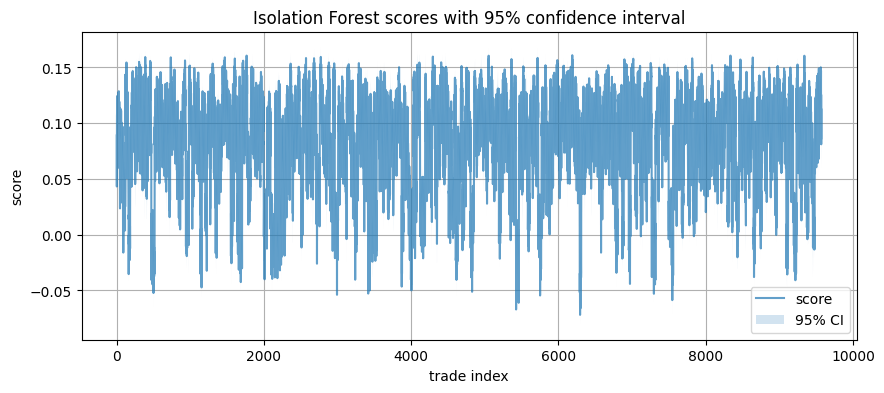

In [56]:
plt.figure(figsize=(10, 4))

idx = np.arange(len(df))

plt.plot(idx, df["iforest_raw_score"], label="score", alpha=0.7)
plt.fill_between(
    idx,
    df["iforest_ci_low"],
    df["iforest_ci_high"],
    alpha=0.2,
    label="95% CI"
)

plt.title("Isolation Forest scores with 95% confidence interval")
plt.xlabel("trade index")
plt.ylabel("score")
plt.legend()
plt.show()


In [57]:
# Simple thresholds (can adjust later)
high_risk_threshold = np.quantile(df["iforest_raw_score"], 0.10)  # lowest 10%
medium_risk_threshold = np.quantile(df["iforest_raw_score"], 0.30)

def map_score_to_risk(score):
    if score <= high_risk_threshold:
        return "HIGH"
    elif score <= medium_risk_threshold:
        return "MEDIUM"
    else:
        return "LOW"

df["risk_level"] = df["iforest_raw_score"].apply(map_score_to_risk)

df[["iforest_raw_score", "risk_level"]].head(10)

,iforest_raw_score,risk_level
0,0.089037,LOW
1,0.043252,MEDIUM
2,0.104345,LOW
3,0.106637,LOW
4,0.108617,LOW
5,0.098020,LOW
6,0.102910,LOW
7,0.124433,LOW
8,0.121240,LOW
9,0.092149,LOW


In [58]:
decision_map = {
    "HIGH":   "Trigger alert + temporarily block large trades",
    "MEDIUM": "Flag for review in admin dashboard",
    "LOW":    "Allow trade (no action)",
}

df["decision"] = df["risk_level"].map(decision_map)

df[[
    "id", "user_id", "amount_staked",
    "iforest_raw_score", "risk_level", "decision"
]].head(15)

,id,user_id,amount_staked,iforest_raw_score,risk_level,decision
0,4005,57,11.92,0.089037,LOW,Allow trade (no action)
1,4006,57,32.43,0.043252,MEDIUM,Flag for review in admin dashboard
2,4007,57,29.45,0.104345,LOW,Allow trade (no action)
3,4008,57,30.70,0.106637,LOW,Allow trade (no action)
4,4009,57,26.48,0.108617,LOW,Allow trade (no action)
5,4010,57,22.13,0.098020,LOW,Allow trade (no action)
6,4011,57,25.85,0.102910,LOW,Allow trade (no action)
7,4012,57,21.60,0.124433,LOW,Allow trade (no action)
8,4013,57,27.85,0.121240,LOW,Allow trade (no action)
9,4014,57,22.65,0.092149,LOW,Allow trade (no action)


In [59]:
risk_counts = df["risk_level"].value_counts(normalize=True).rename("ratio")
print("Risk level distribution:")
print((risk_counts * 100).round(2).astype(str) + " %")

Risk level distribution:
risk_level
LOW        70.0 %
MEDIUM     20.0 %
HIGH      10.01 %
Name: ratio, dtype: object


In [60]:
import joblib

# Save model
joblib.dump(iso_model, "../models/isolation_forest.pkl")

# Save scaler
joblib.dump(scaler, "../models/feature_scaler.pkl")

print("Model and scaler saved!")


Model and scaler saved!
